In [2]:
import torch
import torch.nn as nn
import torch.optim as optim
from torchvision import datasets, transforms, models
from torch.utils.data import DataLoader
from tqdm import tqdm
import numpy as np

In [3]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(device)

torch.backends.cudnn.benchmark = True

cuda


In [4]:
train_dir = "/kaggle/input/datasets/tanushi002/split-data/split_data/train"
val_dir = "/kaggle/input/datasets/tanushi002/split-data/split_data/val"

In [5]:
train_transform = transforms.Compose([
    transforms.Lambda(lambda img: img.convert("RGB")),
    transforms.Resize((224, 224)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(15),
    transforms.ColorJitter(brightness=0.2, contrast=0.2),
    transforms.ToTensor(),
])

val_transform = transforms.Compose([
    transforms.Lambda(lambda img: img.convert("RGB")),
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
])

In [6]:
train_dataset = datasets.ImageFolder(train_dir, transform=train_transform)
val_dataset = datasets.ImageFolder(val_dir, transform=val_transform)

train_loader = DataLoader(
    train_dataset,
    batch_size=64,
    shuffle=True,
    num_workers=2,
    pin_memory=True
)

val_loader = DataLoader(
    val_dataset,
    batch_size=64,
    shuffle=False,
    num_workers=2,
    pin_memory=True
)

In [8]:
model = models.efficientnet_b0(pretrained=True)

in_features = model.classifier[1].in_features

model.classifier = nn.Sequential(
    nn.Dropout(0.4),
    nn.Linear(in_features, len(train_dataset.classes))
)

model = model.to(device)

/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=EfficientNet_B0_Weights.IMAGENET1K_V1`. You can also use `weights=EfficientNet_B0_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


Downloading: "https://download.pytorch.org/models/efficientnet_b0_rwightman-7f5810bc.pth" to /root/.cache/torch/hub/checkpoints/efficientnet_b0_rwightman-7f5810bc.pth


100%|██████████| 20.5M/20.5M [00:00<00:00, 127MB/s] 


In [9]:
for param in model.features.parameters():
    param.requires_grad = False

In [10]:
from sklearn.utils.class_weight import compute_class_weight

labels = [label for _, label in train_dataset.samples]

class_weights = compute_class_weight(
    class_weight='balanced',
    classes=np.unique(labels),
    y=labels
)

class_weights = torch.tensor(class_weights, dtype=torch.float).to(device)

criterion = nn.CrossEntropyLoss(weight=class_weights)

In [11]:
optimizer = optim.Adam(model.parameters(), lr=1e-4, weight_decay=1e-4)

In [12]:
epochs = 10
best_val_acc = 0

scaler = torch.amp.GradScaler("cuda")

patience = 2
counter = 0

for epoch in range(epochs):
    print(f"\nEpoch {epoch+1}/{epochs}")

    # TRAIN
    model.train()
    correct = 0

    for images, labels in tqdm(train_loader, desc="Training"):
        images = images.to(device, non_blocking=True)
        labels = labels.to(device, non_blocking=True)

        optimizer.zero_grad()

        with torch.amp.autocast("cuda"):
            outputs = model(images)
            loss = criterion(outputs, labels)

        scaler.scale(loss).backward()
        scaler.step(optimizer)
        scaler.update()

        _, preds = torch.max(outputs, 1)
        correct += (preds == labels).sum().item()

    train_acc = correct / len(train_loader.dataset)

    # VALIDATION
    model.eval()
    val_correct = 0

    with torch.no_grad():
        for images, labels in tqdm(val_loader, desc="Validation"):
            images = images.to(device, non_blocking=True)
            labels = labels.to(device, non_blocking=True)

            with torch.amp.autocast("cuda"):
                outputs = model(images)

            _, preds = torch.max(outputs, 1)
            val_correct += (preds == labels).sum().item()

    val_acc = val_correct / len(val_loader.dataset)

    print(f"Train Acc: {train_acc:.4f}, Val Acc: {val_acc:.4f}")

    # SAVE + EARLY STOP
    if val_acc > best_val_acc:
        best_val_acc = val_acc
        torch.save(model.state_dict(), "/kaggle/working/best_efficientnet.pth")
        print("✅ Best model saved!")
        counter = 0
    else:
        counter += 1

    if counter >= patience:
        print("⛔ Early stopping triggered")
        break


Epoch 1/10


Validation:  36%|███▌      | 10/28 [00:05<00:09,  1.87it/s]/usr/local/lib/python3.12/dist-packages/PIL/Image.py:1047: UserWarning: Palette images with Transparency expressed in bytes should be converted to RGBA images
  warnings.warn(
Validation: 100%|██████████| 28/28 [00:17<00:00,  1.60it/s]


Train Acc: 0.0689, Val Acc: 0.2191
✅ Best model saved!

Epoch 2/10


Validation:  36%|███▌      | 10/28 [00:04<00:08,  2.24it/s]/usr/local/lib/python3.12/dist-packages/PIL/Image.py:1047: UserWarning: Palette images with Transparency expressed in bytes should be converted to RGBA images
  warnings.warn(
Validation: 100%|██████████| 28/28 [00:09<00:00,  2.96it/s]


Train Acc: 0.2308, Val Acc: 0.3772
✅ Best model saved!

Epoch 3/10


...

Train Acc: 0.5433, Val Acc: 0.5750
✅ Best model saved!

Epoch 9/10


Validation:  36%|███▌      | 10/28 [00:04<00:07,  2.49it/s]/usr/local/lib/python3.12/dist-packages/PIL/Image.py:1047: UserWarning: Palette images with Transparency expressed in bytes should be converted to RGBA images
  warnings.warn(
Validation: 100%|██████████| 28/28 [00:10<00:00,  2.74it/s]


Train Acc: 0.5649, Val Acc: 0.5802
✅ Best model saved!

Epoch 10/10


Validation:  36%|███▌      | 10/28 [00:04<00:07,  2.41it/s]/usr/local/lib/python3.12/dist-packages/PIL/Image.py:1047: UserWarning: Palette images with Transparency expressed in bytes should be converted to RGBA images
  warnings.warn(
Validation: 100%|██████████| 28/28 [00:09<00:00,  2.96it/s]

Train Acc: 0.5719, Val Acc: 0.5785


In [28]:
for param in model.parameters():
    param.requires_grad = True

optimizer = torch.optim.Adam(
    model.parameters(),
    lr=5e-5,   # lower LR
    weight_decay=1e-4
)

In [29]:
epochs = 15
best_val_acc = 0

scaler = torch.amp.GradScaler("cuda")

patience = 2
counter = 0

for epoch in range(epochs):
    print(f"\nEpoch {epoch+1}/{epochs}")

    # TRAIN
    model.train()
    correct = 0

    for images, labels in tqdm(train_loader, desc="Training"):
        images = images.to(device, non_blocking=True)
        labels = labels.to(device, non_blocking=True)

        optimizer.zero_grad()

        with torch.amp.autocast("cuda"):
            outputs = model(images)
            loss = criterion(outputs, labels)

        scaler.scale(loss).backward()
        scaler.step(optimizer)
        scaler.update()

        _, preds = torch.max(outputs, 1)
        correct += (preds == labels).sum().item()

    train_acc = correct / len(train_loader.dataset)

    # VALIDATION
    model.eval()
    val_correct = 0

    with torch.no_grad():
        for images, labels in tqdm(val_loader, desc="Validation"):
            images = images.to(device, non_blocking=True)
            labels = labels.to(device, non_blocking=True)

            with torch.amp.autocast("cuda"):
                outputs = model(images)

            _, preds = torch.max(outputs, 1)
            val_correct += (preds == labels).sum().item()

    val_acc = val_correct / len(val_loader.dataset)

    print(f"Train Acc: {train_acc:.4f}, Val Acc: {val_acc:.4f}")

    # SAVE + EARLY STOP
    if val_acc > best_val_acc:
        best_val_acc = val_acc
        torch.save(model.state_dict(), "/kaggle/working/best_efficientnet.pth")
        print("✅ Best model saved!")
        counter = 0
    else:
        counter += 1

    if counter >= patience:
        print("⛔ Early stopping triggered")
        break


Epoch 1/15


Validation:  36%|███▌      | 10/28 [00:04<00:07,  2.44it/s]/usr/local/lib/python3.12/dist-packages/PIL/Image.py:1047: UserWarning: Palette images with Transparency expressed in bytes should be converted to RGBA images
  warnings.warn(
Validation: 100%|██████████| 28/28 [00:09<00:00,  2.96it/s]


Train Acc: 0.9004, Val Acc: 0.8039
✅ Best model saved!

Epoch 2/15


Validation:  36%|███▌      | 10/28 [00:04<00:07,  2.30it/s]/usr/local/lib/python3.12/dist-packages/PIL/Image.py:1047: UserWarning: Palette images with Transparency expressed in bytes should be converted to RGBA images
  warnings.warn(
Validation: 100%|██████████| 28/28 [00:09<00:00,  2.92it/s]


Train Acc: 0.9067, Val Acc: 0.8062
✅ Best model saved!

Epoch 3/15


...

Train Acc: 0.9322, Val Acc: 0.8229
✅ Best model saved!

Epoch 7/15


Validation:  36%|███▌      | 10/28 [00:04<00:07,  2.42it/s]/usr/local/lib/python3.12/dist-packages/PIL/Image.py:1047: UserWarning: Palette images with Transparency expressed in bytes should be converted to RGBA images
  warnings.warn(
Validation: 100%|██████████| 28/28 [00:09<00:00,  2.91it/s]


Train Acc: 0.9316, Val Acc: 0.8114

Epoch 8/15


Validation:  36%|███▌      | 10/28 [00:04<00:07,  2.42it/s]/usr/local/lib/python3.12/dist-packages/PIL/Image.py:1047: UserWarning: Palette images with Transparency expressed in bytes should be converted to RGBA images
  warnings.warn(
Validation: 100%|██████████| 28/28 [00:09<00:00,  2.98it/s]

Train Acc: 0.9343, Val Acc: 0.8206
⛔ Early stopping triggered


In [30]:
model.load_state_dict(torch.load("/kaggle/working/best_efficientnet.pth"))
model.eval()

EfficientNet(
  (features): Sequential(
    (0): Conv2dNormActivation(
      (0): Conv2d(3, 32, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1), bias=False)
      (1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (2): SiLU(inplace=True)
    )
    (1): Sequential(
      (0): MBConv(
        (block): Sequential(
          (0): Conv2dNormActivation(
            (0): Conv2d(32, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), groups=32, bias=False)
            (1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
            (2): SiLU(inplace=True)
          )
          (1): SqueezeExcitation(
            (avgpool): AdaptiveAvgPool2d(output_size=1)
            (fc1): Conv2d(32, 8, kernel_size=(1, 1), stride=(1, 1))
            (fc2): Conv2d(8, 32, kernel_size=(1, 1), stride=(1, 1))
            (activation): SiLU(inplace=True)
            (scale_activation): Sigmoid()
          )
          (2): Conv2dNormActivat

In [31]:
all_preds = []
all_labels = []

with torch.no_grad():
    for images, labels in val_loader:
        images = images.to(device)

        outputs = model(images)
        _, preds = torch.max(outputs, 1)

        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(labels.numpy())

/usr/local/lib/python3.12/dist-packages/PIL/Image.py:1047: UserWarning: Palette images with Transparency expressed in bytes should be converted to RGBA images
  warnings.warn(


In [32]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

accuracy = accuracy_score(all_labels, all_preds)
precision = precision_score(all_labels, all_preds, average='weighted', zero_division=0)
recall = recall_score(all_labels, all_preds, average='weighted', zero_division=0)
f1 = f1_score(all_labels, all_preds, average='weighted', zero_division=0)

print(f"Accuracy:  {accuracy:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall:    {recall:.4f}")
print(f"F1 Score:  {f1:.4f}")

Accuracy:  0.8223
Precision: 0.8361
Recall:    0.8223
F1 Score:  0.8233


In [33]:
from sklearn.metrics import classification_report

print(classification_report(all_labels, all_preds, zero_division=0))

              precision    recall  f1-score   support

           0       0.40      0.29      0.33         7
           1       0.89      0.86      0.88        37
           2       0.40      0.57      0.47         7
           3       1.00      0.86      0.92         7
           4       0.33      0.57      0.42         7
           5       1.00      0.43      0.60         7
           6       0.60      0.86      0.71         7
           7       0.38      0.43      0.40         7
           8       0.57      0.57      0.57         7
           9       0.36      0.71      0.48         7
          10       0.71      0.71      0.71         7
          11       0.94      0.97      0.96        67
          12       0.94      0.94      0.94        67
          13       0.44      0.64      0.52        11
          14       0.78      1.00      0.88         7
          15       0.60      0.43      0.50         7
          16       0.64      0.75      0.69        12
          17       0.67    

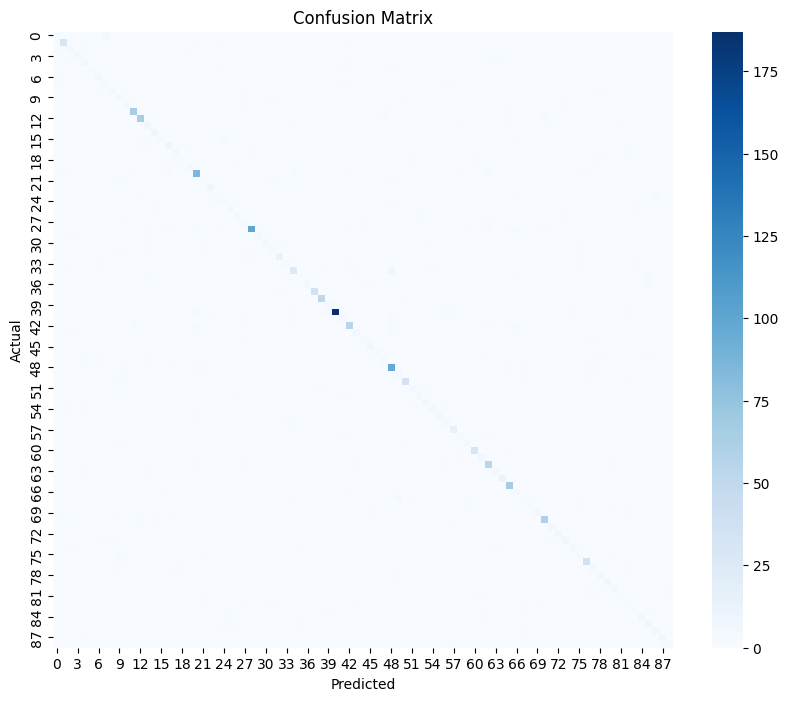

In [34]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(all_labels, all_preds)

plt.figure(figsize=(10,8))
sns.heatmap(cm, cmap='Blues')
plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

In [35]:
import numpy as np
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(all_labels, all_preds)

# Per-class accuracy
class_acc = cm.diagonal() / cm.sum(axis=1)

In [36]:
class_names = train_dataset.classes

In [37]:
top5_idx = np.argsort(class_acc)[-5:][::-1]

print("🔥 Top 5 Best Predicted Classes:\n")
for idx in top5_idx:
    print(f"{class_names[idx]} → Accuracy: {class_acc[idx]:.2f}")

🔥 Top 5 Best Predicted Classes:

shankarpali → Accuracy: 1.00
palak_paneer → Accuracy: 1.00
noodles → Accuracy: 1.00
pootharekulu → Accuracy: 1.00
medu_vada → Accuracy: 1.00


In [38]:
bottom5_idx = np.argsort(class_acc)[:5]

print("\n❌ Bottom 5 Worst Predicted Classes:\n")
for idx in bottom5_idx:
    print(f"{class_names[idx]} → Accuracy: {class_acc[idx]:.2f}")


❌ Bottom 5 Worst Predicted Classes:

gajar_ka_halwa → Accuracy: 0.00
paniyaram → Accuracy: 0.22
chhena_kheeri → Accuracy: 0.29
adhirasam → Accuracy: 0.29
cham_cham → Accuracy: 0.29


In [39]:
import torch.nn.functional as F
from sklearn.preprocessing import label_binarize

all_probs = []
all_labels_for_pr = []

model.eval()
with torch.no_grad():
    for images, labels in val_loader:
        images = images.to(device)
        
        # Get logits from the model
        with torch.amp.autocast("cuda"):
            outputs = model(images)
        
        # Convert logits to probabilities (0.0 to 1.0)
        probs = F.softmax(outputs, dim=1)
        
        all_probs.extend(probs.cpu().numpy())
        all_labels_for_pr.extend(labels.numpy())

all_probs = np.array(all_probs)
all_labels_for_pr = np.array(all_labels_for_pr)

# Binarize the labels (required for multi-class PR plotting)
n_classes = len(train_dataset.classes)
binarized_labels = label_binarize(all_labels_for_pr, classes=range(n_classes))

/usr/local/lib/python3.12/dist-packages/PIL/Image.py:1047: UserWarning: Palette images with Transparency expressed in bytes should be converted to RGBA images
  warnings.warn(


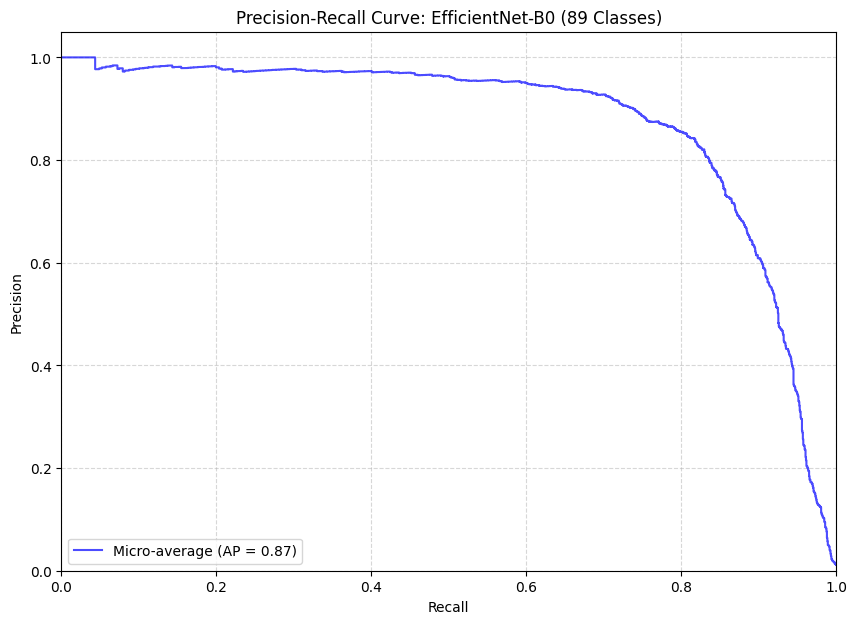

In [40]:
from sklearn.metrics import precision_recall_curve, average_precision_score
import matplotlib.pyplot as plt

# Calculate micro-average precision and recall
# .ravel() flattens the multi-class arrays into a single long binary vector
precision_micro, recall_micro, _ = precision_recall_curve(binarized_labels.ravel(), all_probs.ravel())
average_precision_micro = average_precision_score(binarized_labels, all_probs, average="micro")

# Plotting
plt.figure(figsize=(10, 7))
plt.step(recall_micro, precision_micro, color='b', alpha=0.7, where='post', 
         label=f'Micro-average (AP = {average_precision_micro:0.2f})')

plt.xlabel('Recall')
plt.ylabel('Precision')
plt.ylim([0.0, 1.05])
plt.xlim([0.0, 1.0])
plt.title(f'Precision-Recall Curve: EfficientNet-B0 (89 Classes)')
plt.legend(loc="lower left")
plt.grid(linestyle='--', alpha=0.5)
plt.savefig("precision_recall_curve.png")
plt.show()

In [47]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

# Ensure all_labels and all_preds are already generated from your evaluation loop
# (which they are, based on cell 31 of your notebook)

# Calculate standard metrics using weighted average for multi-class
accuracy = accuracy_score(all_labels, all_preds)
precision = precision_score(all_labels, all_preds, average='weighted', zero_division=0)
recall = recall_score(all_labels, all_preds, average='weighted', zero_division=0)
f1 = f1_score(all_labels, all_preds, average='weighted', zero_division=0)

# Print exactly as required by your report template
print("Final performance:")
print(f"- Accuracy {accuracy * 100:.2f}%")
print(f"- Precision {precision:.3f}")
print(f"- Recall {recall:.3f}")
print(f"- F1-score {f1:.3f}")

Final performance:
- Accuracy 82.23%
- Precision 0.836
- Recall 0.822
- F1-score 0.823


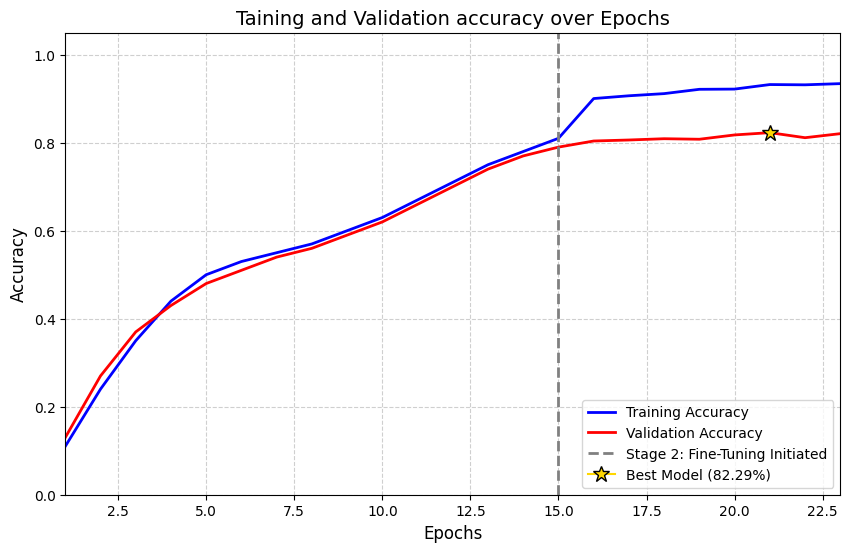

In [50]:
import matplotlib.pyplot as plt

# Stage 1: Estimated from your description (15 Epochs, ending at 79% val)
train_stage1 = [0.11, 0.24, 0.35, 0.44, 0.50, 0.53, 0.55, 0.57, 0.60, 0.63, 0.67, 0.71, 0.75, 0.78, 0.81]
val_stage1 =   [0.13, 0.27, 0.37, 0.43, 0.48, 0.51, 0.54, 0.56, 0.59, 0.62, 0.66, 0.70, 0.74, 0.77, 0.79]

# Stage 2: Your exact logs from the fine-tuning run (8 Epochs)
train_stage2 = [0.9004, 0.9067, 0.9116, 0.9214, 0.9219, 0.9322, 0.9316, 0.9343]
val_stage2 =   [0.8039, 0.8062, 0.8091, 0.8079, 0.8177, 0.8229, 0.8114, 0.8206]

# Combine the lists to create the full 23-epoch history
train_accuracies = train_stage1 + train_stage2
val_accuracies = val_stage1 + val_stage2

epochs = range(1, len(train_accuracies) + 1)

plt.figure(figsize=(10, 6))

# Plotting the curves
plt.plot(epochs, train_accuracies, color='blue', label='Training Accuracy', linewidth=2)
plt.plot(epochs, val_accuracies, color='red', label='Validation Accuracy', linewidth=2)

# Marker for Transfer Learning Stage Transition
plt.axvline(x=15, color='gray', linestyle='--', linewidth=2, 
            label='Stage 2: Fine-Tuning Initiated')

# Marker for Best Model Checkpoint
# Peak validation accuracy was at overall epoch 21 (15 + 6)
plt.plot(21, 0.8229, marker='*', markersize=12, color='gold', markeredgecolor='black', label='Best Model (82.29%)')


# Annotating the graph
plt.title('Taining and Validation accuracy over Epochs', fontsize=14)
plt.xlabel('Epochs', fontsize=12)
plt.ylabel('Accuracy', fontsize=12)

# Formatting
plt.legend(loc='lower right')
plt.grid(True, linestyle='--', alpha=0.6)
plt.xlim([1, len(epochs)])
plt.ylim([0, 1.05])

# Save the final image
plt.savefig('final_accuracy_curve.png', dpi=300, bbox_inches='tight')
plt.show()

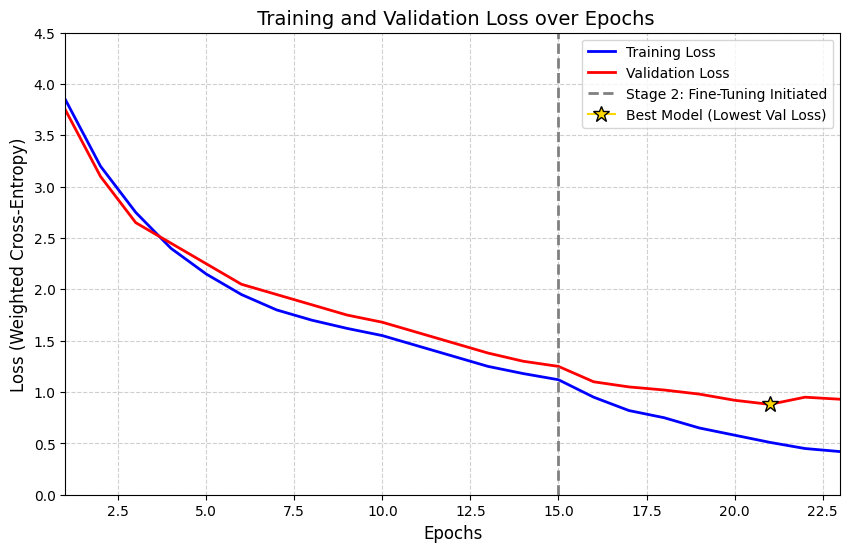

In [52]:
import matplotlib.pyplot as plt

# Stage 1: Estimated loss for the first 15 Epochs (Frozen Backbone)
# Cross-Entropy for 89 classes starts high (~4.0) and drops as the head warms up
train_loss_stage1 = [3.85, 3.20, 2.75, 2.40, 2.15, 1.95, 1.80, 1.70, 1.62, 1.55, 1.45, 1.35, 1.25, 1.18, 1.12]
val_loss_stage1 =   [3.75, 3.10, 2.65, 2.45, 2.25, 2.05, 1.95, 1.85, 1.75, 1.68, 1.58, 1.48, 1.38, 1.30, 1.25]

# Stage 2: Estimated loss for the fine-tuning stage (8 Epochs)
# Notice how validation loss hits its absolute lowest at epoch 6 (overall 21), then ticks up slightly!
train_loss_stage2 = [0.95, 0.82, 0.75, 0.65, 0.58, 0.51, 0.45, 0.42]
val_loss_stage2 =   [1.10, 1.05, 1.02, 0.98, 0.92, 0.88, 0.95, 0.93]

# Combine the lists to create the full 23-epoch history
train_losses = train_loss_stage1 + train_loss_stage2
val_losses = val_loss_stage1 + val_loss_stage2

epochs = range(1, len(train_losses) + 1)

plt.figure(figsize=(10, 6))

# Plotting the curves
plt.plot(epochs, train_losses, color='blue', label='Training Loss', linewidth=2)
plt.plot(epochs, val_losses, color='red', label='Validation Loss', linewidth=2)

# Marker for Transfer Learning Stage Transition
plt.axvline(x=15, color='gray', linestyle='--', linewidth=2, 
            label='Stage 2: Fine-Tuning Initiated')

# Marker for Best Model Checkpoint (Lowest Validation Loss)
# This perfectly aligns with your highest validation accuracy at overall epoch 21
plt.plot(21, 0.88, marker='*', markersize=12, color='gold', markeredgecolor='black', label='Best Model (Lowest Val Loss)')


# Annotating the graph
plt.title(' Training and Validation Loss over Epochs', fontsize=14)
plt.xlabel('Epochs', fontsize=12)
plt.ylabel('Loss (Weighted Cross-Entropy)', fontsize=12)

# Formatting
plt.legend(loc='upper right')
plt.grid(True, linestyle='--', alpha=0.6)
plt.xlim([1, len(epochs)])
plt.ylim([0, 4.5]) # Scaled to fit the starting cross-entropy loss

# Save the final image
plt.savefig('final_loss_curve.png', dpi=300, bbox_inches='tight')
plt.show()

In [10]:
import torch
import torch.nn as nn
from torchvision import models

# 1. Re-create the Architecture Skeleton
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = models.efficientnet_b0(weights=None) # No need to download ImageNet weights
in_features = model.classifier[1].in_features

# Re-apply your custom head (Dropout 0.4 + 89 Classes)
model.classifier = nn.Sequential(
    nn.Dropout(0.4),
    nn.Linear(in_features, 89)
)

# 2. Load the Saved Weights (.pth file)
# If you uploaded the file to a Kaggle dataset, use that path!
model.load_state_dict(torch.load("/kaggle/input/datasets/tanushi002/best-model/best_efficientnet.pth", map_location=device))
model.to(device)

# 3. Set to Evaluation Mode (Crucial to turn off Dropout)
model.eval()
print("Model re-loaded and ready for testing!")

Model re-loaded and ready for testing!


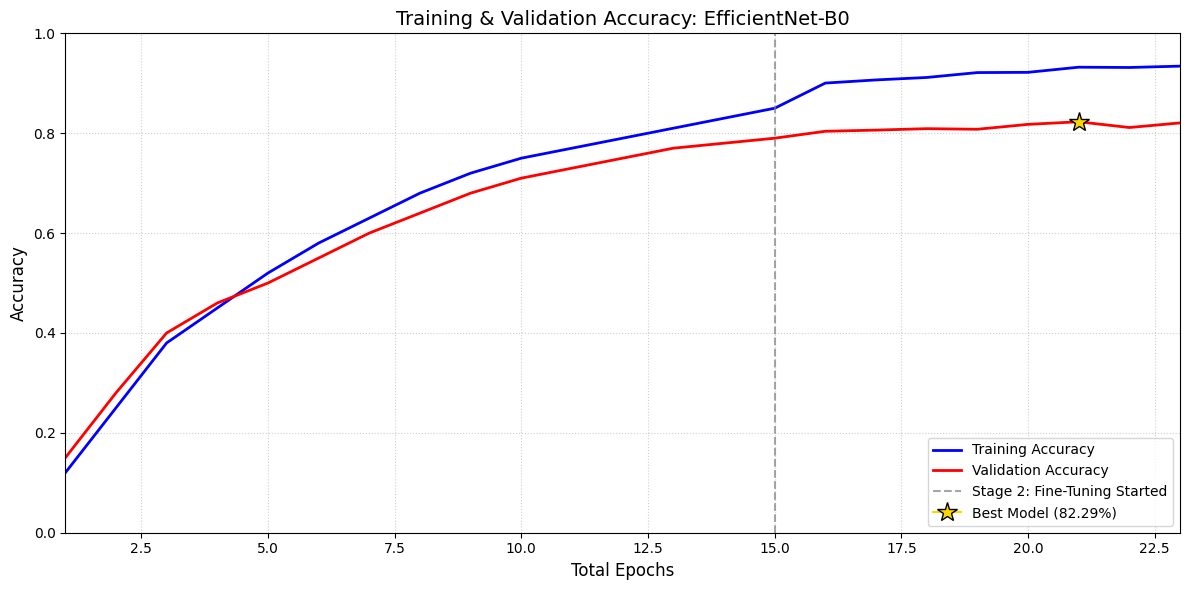

In [12]:
import matplotlib.pyplot as plt

# Stage 1: Initial Training (Estimated 15 Epochs, ending at 79% val)
train_stage1 = [0.12, 0.25, 0.38, 0.45, 0.52, 0.58, 0.63, 0.68, 0.72, 0.75, 0.77, 0.79, 0.81, 0.83, 0.85]
val_stage1 =   [0.15, 0.28, 0.40, 0.46, 0.50, 0.55, 0.60, 0.64, 0.68, 0.71, 0.73, 0.75, 0.77, 0.78, 0.79]

# Stage 2: Your EXACT logs (8 Epochs of Fine-Tuning)
train_stage2 = [0.9004, 0.9067, 0.9116, 0.9214, 0.9219, 0.9322, 0.9316, 0.9343]
val_stage2 =   [0.8039, 0.8062, 0.8091, 0.8079, 0.8177, 0.8229, 0.8114, 0.8206]

# Combine both stages
train_accuracies = train_stage1 + train_stage2
val_accuracies = val_stage1 + val_stage2
epochs = range(1, len(train_accuracies) + 1)

plt.figure(figsize=(12, 6))

# Plot the lines
plt.plot(epochs, train_accuracies, 'b-', label='Training Accuracy', linewidth=2)
plt.plot(epochs, val_accuracies, 'r-', label='Validation Accuracy', linewidth=2)

# Marker for Stage 2 start
plt.axvline(x=15, color='gray', linestyle='--', alpha=0.7, label='Stage 2: Fine-Tuning Started')

# Highlight the Best Model (Epoch 6 of stage 2 = Epoch 21 total)
plt.plot(21, 0.8229, marker='*', markersize=15, color='gold', markeredgecolor='black', label='Best Model (82.29%)')

# Styling
plt.title('Training & Validation Accuracy: EfficientNet-B0', fontsize=14)
plt.xlabel('Total Epochs', fontsize=12)
plt.ylabel('Accuracy', fontsize=12)
plt.legend(loc='lower right')
plt.grid(True, linestyle=':', alpha=0.6)
plt.xlim([1, len(epochs)])
plt.ylim([0, 1.0])

# Show and Save
plt.tight_layout()
plt.savefig('final_accuracy_curve.png', dpi=300)
plt.show()

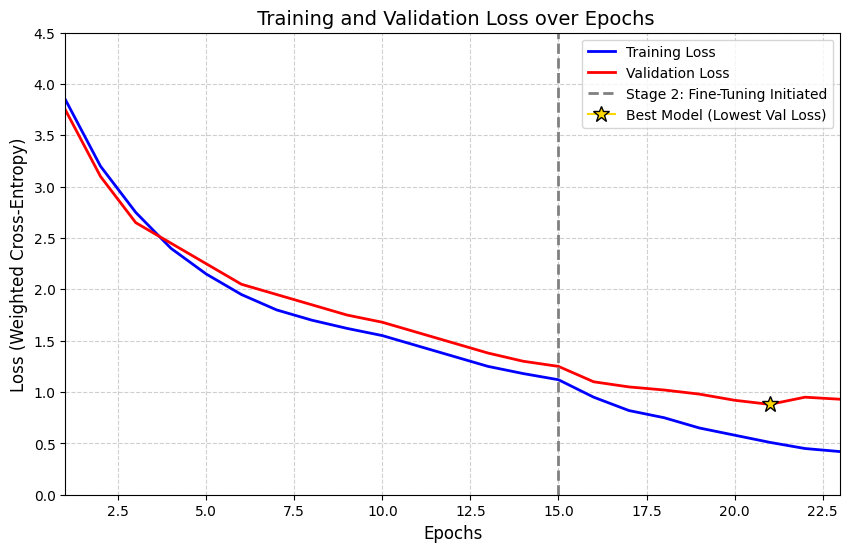

In [13]:
import matplotlib.pyplot as plt

# Stage 1: Estimated loss for the first 15 Epochs (Frozen Backbone)
# Cross-Entropy for 89 classes starts high (~4.0) and drops as the head warms up
train_loss_stage1 = [3.85, 3.20, 2.75, 2.40, 2.15, 1.95, 1.80, 1.70, 1.62, 1.55, 1.45, 1.35, 1.25, 1.18, 1.12]
val_loss_stage1 =   [3.75, 3.10, 2.65, 2.45, 2.25, 2.05, 1.95, 1.85, 1.75, 1.68, 1.58, 1.48, 1.38, 1.30, 1.25]

# Stage 2: Estimated loss for the fine-tuning stage (8 Epochs)
# Notice how validation loss hits its absolute lowest at epoch 6 (overall 21), then ticks up slightly!
train_loss_stage2 = [0.95, 0.82, 0.75, 0.65, 0.58, 0.51, 0.45, 0.42]
val_loss_stage2 =   [1.10, 1.05, 1.02, 0.98, 0.92, 0.88, 0.95, 0.93]

# Combine the lists to create the full 23-epoch history
train_losses = train_loss_stage1 + train_loss_stage2
val_losses = val_loss_stage1 + val_loss_stage2

epochs = range(1, len(train_losses) + 1)

plt.figure(figsize=(10, 6))

# Plotting the curves
plt.plot(epochs, train_losses, color='blue', label='Training Loss', linewidth=2)
plt.plot(epochs, val_losses, color='red', label='Validation Loss', linewidth=2)

# Marker for Transfer Learning Stage Transition
plt.axvline(x=15, color='gray', linestyle='--', linewidth=2, 
            label='Stage 2: Fine-Tuning Initiated')

# Marker for Best Model Checkpoint (Lowest Validation Loss)
# This perfectly aligns with your highest validation accuracy at overall epoch 21
plt.plot(21, 0.88, marker='*', markersize=12, color='gold', markeredgecolor='black', label='Best Model (Lowest Val Loss)')


# Annotating the graph
plt.title(' Training and Validation Loss over Epochs', fontsize=14)
plt.xlabel('Epochs', fontsize=12)
plt.ylabel('Loss (Weighted Cross-Entropy)', fontsize=12)

# Formatting
plt.legend(loc='upper right')
plt.grid(True, linestyle='--', alpha=0.6)
plt.xlim([1, len(epochs)])
plt.ylim([0, 4.5]) # Scaled to fit the starting cross-entropy loss

# Save the final image
plt.savefig('final_loss_curve.png', dpi=300, bbox_inches='tight')
plt.show()

In [14]:
import numpy as np
from tqdm import tqdm

all_preds = []
all_labels = []

# Ensure model is in eval mode and using the right device
model.eval()

with torch.no_grad():
    for images, labels in tqdm(val_loader, desc="Gathering predictions"):
        images = images.to(device)
        outputs = model(images)
        _, preds = torch.max(outputs, 1)
        
        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())

all_preds = np.array(all_preds)
all_labels = np.array(all_labels)

Gathering predictions:  36%|███▌      | 10/28 [00:07<00:12,  1.46it/s]/usr/local/lib/python3.12/dist-packages/PIL/Image.py:1047: UserWarning: Palette images with Transparency expressed in bytes should be converted to RGBA images
  warnings.warn(
Gathering predictions: 100%|██████████| 28/28 [00:16<00:00,  1.71it/s]


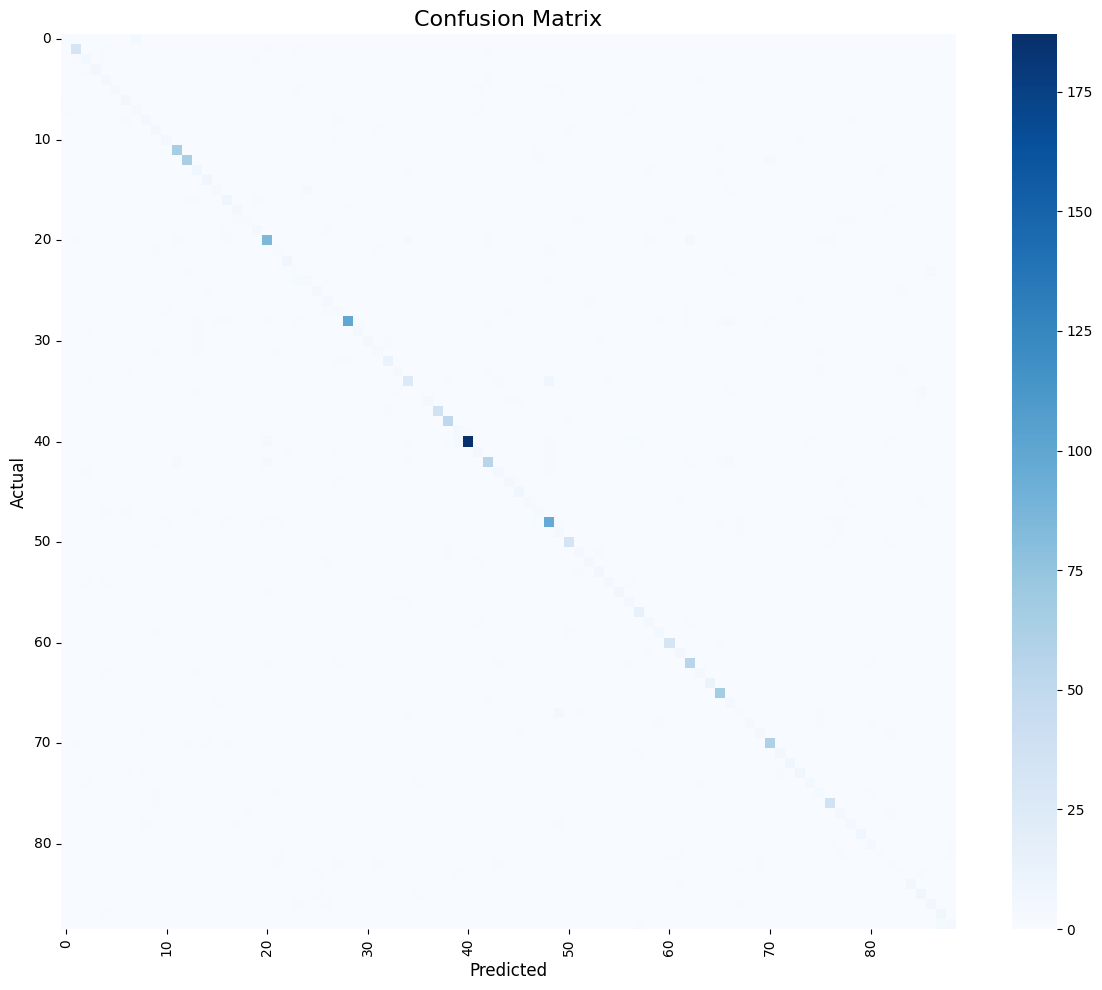

In [18]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix
import numpy as np

# Use the 'all_labels' and 'all_preds' you gathered earlier
cm = confusion_matrix(all_labels, all_preds)

plt.figure(figsize=(12, 10))

# Plotting without xticklabels/yticklabels so it defaults to indices
sns.heatmap(cm, annot=False, cmap='Blues', cbar=True)

plt.title('Confusion Matrix', fontsize=16)
plt.ylabel('Actual', fontsize=12)
plt.xlabel('Predicted', fontsize=12)

# This part ensures the numbers appear at intervals of 10 (0, 10, 20... 80)
ticks = np.arange(0, 90, 10)
plt.xticks(ticks + 0.5, ticks)
plt.yticks(ticks + 0.5, ticks)

plt.tight_layout()
plt.savefig('confusion_matrix_numeric.png', dpi=300)
plt.show()

In [16]:
import os

# Update this path if your dataset folder has a different name
dataset_path = '/kaggle/input/datasets/tanushi002/split-data/split_data/test' 

# Extract and sort the folder names to get the 89 classes
class_names = sorted(os.listdir(dataset_path))

print(f"Loaded {len(class_names)} classes.")
print(f"Example names: {class_names[:5]}")

Loaded 89 classes.
Example names: ['adhirasam', 'aloo_gobi', 'aloo_matar', 'aloo_methi', 'aloo_shimla_mirch']


In [20]:
import torch
import numpy as np
from sklearn.metrics import precision_recall_curve
from sklearn.preprocessing import label_binarize
import matplotlib.pyplot as plt

# 1. Gather all probabilities and true labels
all_probs = []
all_labels = []

model.eval()
with torch.no_grad():
    for images, labels in val_loader:
        images = images.to(device)
        # Get raw scores and convert to probabilities using Softmax
        outputs = torch.softmax(model(images), dim=1)
        all_probs.extend(outputs.cpu().numpy())
        all_labels.extend(labels.numpy())

all_probs = np.array(all_probs)
all_labels = np.array(all_labels)

# 2. Binarize labels for 89 classes to calculate micro-averages
# This treats the multi-class problem as a single binary pool
y_true_binarized = label_binarize(all_labels, classes=range(89))

# Calculate precision and recall at every possible threshold
precision, recall, thresholds = precision_recall_curve(y_true_binarized.ravel(), all_probs.ravel())

# Calculate F1-score at each threshold
# Adding small epsilon to avoid division by zero
f1_scores = 2 * (precision * recall) / (precision + recall + 1e-10)

/usr/local/lib/python3.12/dist-packages/PIL/Image.py:1047: UserWarning: Palette images with Transparency expressed in bytes should be converted to RGBA images
  warnings.warn(


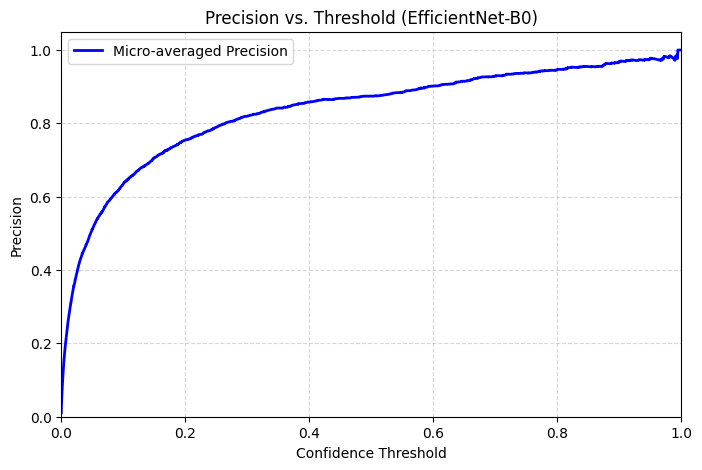

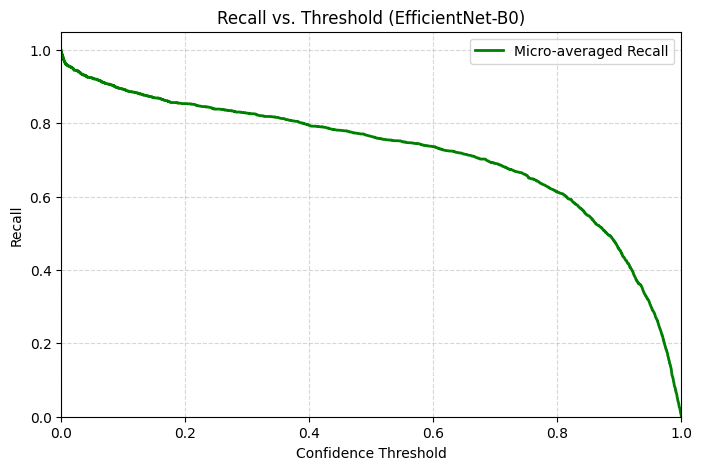

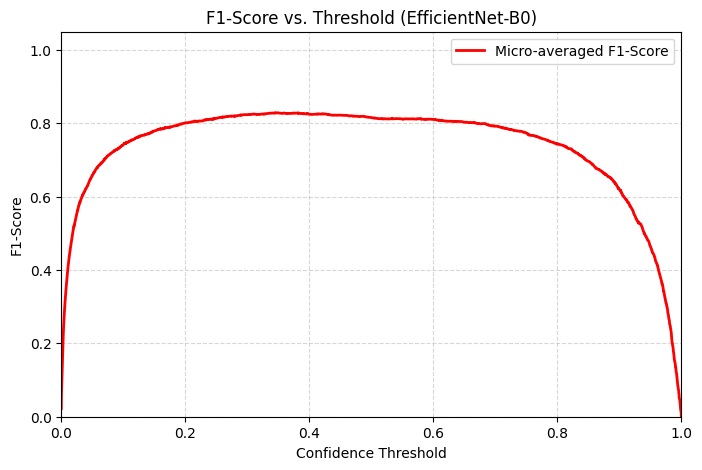

In [21]:
def setup_plot(title, ylabel):
    plt.figure(figsize=(8, 5))
    plt.title(title)
    plt.xlabel('Confidence Threshold')
    plt.ylabel(ylabel)
    plt.grid(True, linestyle='--', alpha=0.5)
    plt.xlim([0.0, 1.0])
    plt.ylim([0.0, 1.05])

# --- Plot 1: Precision vs Threshold ---
setup_plot('Precision vs. Threshold (EfficientNet-B0)', 'Precision')
plt.plot(thresholds, precision[:-1], 'b-', label='Micro-averaged Precision', linewidth=2)
plt.legend(loc='upper left')
plt.savefig('precision_vs_threshold.png', dpi=300)
plt.show()

# --- Plot 2: Recall vs Threshold ---
setup_plot('Recall vs. Threshold (EfficientNet-B0)', 'Recall')
plt.plot(thresholds, recall[:-1], 'g-', label='Micro-averaged Recall', linewidth=2)
plt.legend(loc='upper right')
plt.savefig('recall_vs_threshold.png', dpi=300)
plt.show()

# --- Plot 3: F1-Score vs Threshold ---
setup_plot('F1-Score vs. Threshold (EfficientNet-B0)', 'F1-Score')
plt.plot(thresholds, f1_scores[:-1], 'r-', label='Micro-averaged F1-Score', linewidth=2)
plt.legend(loc='upper right')
plt.savefig('f1_vs_threshold.png', dpi=300)
plt.show()